# 第三次報告：BERT（Encoder-only model）應用於 PTT WomenTalk「難過」貼文分析

本 notebook 依據第十二週課程 **BERT (Encoder-only model)** 的大綱製作，並延續本組第一次與第二次報告的研究脈絡，使用資料集 `sna2026s_11_3222ae0c1b_33.csv` 進行分析。

本次報告核心目標：

1. 介紹 BERT / Transformer 相關套件與使用方式。
2. 將 PTT 中文貼文整理成可供 BERT 任務使用的資料格式。
3. 示範 Token Classification：NER 命名實體辨識。
4. 示範 Sequence Classification：Sentiment Classification 與 Relation Extraction。
5. 使用 BERTopic 進行 Text Clustering，並套用中文資料與 Representation 方法優化主題表示。

> 注意：本 notebook 使用 Hugging Face 與 BERTopic 相關模型，若第一次執行，需連線下載模型。若環境沒有 GPU，建議先用抽樣資料執行。


## 0. 環境、套件與執行提醒

建議在 Google Colab 或課堂指定環境中執行。本 notebook 會優先使用「輕量抽樣」方式示範，避免 BERT 與 BERTopic 執行時間過長。

若尚未安裝套件，可先執行下一格。若已安裝，可略過。


In [ ]:
# 若在 Colab 或新環境第一次執行，可取消註解安裝
# !pip install -U pandas numpy matplotlib scikit-learn jieba tqdm
# !pip install -U transformers sentence-transformers bertopic hdbscan umap-learn
# !pip install -U opencc-python-reimplemented


## 1. 套件介紹

本次報告主要使用以下套件：

| 套件 | 用途 |
|---|---|
| `pandas`, `numpy` | 資料讀取、表格整理與統計 |
| `re`, `jieba` | 中文文字清理與斷詞 |
| `transformers` | 載入 Hugging Face 上的 BERT 模型與 pipeline |
| `sentence_transformers` | 將中文貼文轉換成語意向量 embeddings |
| `BERTopic` | 結合 embedding、降維、分群與 c-TF-IDF 的主題模型 |
| `CountVectorizer` | 建立詞彙矩陣，並搭配中文斷詞 |
| `KMeans` / `HDBSCAN` | 主題分群模型 |
| `matplotlib` | 視覺化分析結果 |


In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)

DATA_PATH = Path('sna2026s_11_3222ae0c1b_33.csv')
if not DATA_PATH.exists():
    # 在 ChatGPT 產出的沙盒環境中，檔案位置如下；在 Colab 請放在目前工作目錄即可
    DATA_PATH = Path('/content/sna2026s_11_3222ae0c1b_33.csv')

print('資料路徑：', DATA_PATH)
print('檔案是否存在：', DATA_PATH.exists())


資料路徑： sna2026s_11_3222ae0c1b_33.csv
檔案是否存在： True


## 2. 資料前處理

本組資料來源為 PTT WomenTalk 板，主要分析單位為「一篇文章」。本段會完成：

1. 讀取資料集。
2. 檢查欄位、筆數與資料期間。
3. 抽取標題分類標籤，例如 `[難過]`、`[閒聊]`、`[心情]`。
4. 清理文章內容，移除網址、PTT 簽名檔、特殊符號與過短文章。
5. 建立 `doc_text` 欄位，作為 BERT / BERTopic 的輸入文本。


In [3]:
df_raw = pd.read_csv(DATA_PATH)
print('資料筆數與欄位數：', df_raw.shape)
display(df_raw.head(3))
print(df_raw.columns.tolist())


資料筆數與欄位數： (7571, 11)


,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/WomenTalk/M.1609431742.A.E16.html,[難過]2020年12月步數不足,2021-01-01 00:22:20,johanzhou,WomenTalk,2020年12月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。\n\n平均一天也不到一萬步。\nhttp://i.imgur.com/Ml84eEr.jpg\n三十多萬步而已：（\n\n\n-\nSent ...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""rukawa514"", ""cmtContent"": "":很強了好不好"", ""cmtDate"": ""2021-01-01 00:50:00""}, {""cmtStatu...",42.74.30.7,2021-01-01 00:56:55,ptt
1,2,https://www.ptt.cc/bbs/WomenTalk/M.1609453123.A.CCF.html,[難過]陽台又淹水了,2021-01-01 06:18:41,ffooxx,WomenTalk,大家...早安，我芙尼。\n\n大概五點的時候我被一陣電鈴聲吵醒，\n門一打開發現是樓下的鄰居，\n她問我我家的陽台是不是又淹水了，\n因為他們家的廚房又漏水了，\n我嚇一跳衝去陽台看，\n結果洗衣機接水龍頭的地方又壞了QAQ\n\...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""molopo"", ""cmtContent"": "":多次發生請專業來修吧"", ""cmtDate"": ""2021-01-01 17:15:00""}, {""cmtStat...",49.216.68.245,2021-01-02 00:46:24,ptt
2,3,https://www.ptt.cc/bbs/WomenTalk/M.1609473812.A.54F.html,[閒聊]關於朋友這件事：（,2021-01-01 12:03:30,winnie5286,WomenTalk,不知道是不是年紀的關係..\n真的感覺身邊都沒有朋友了。\n以為是真心的朋友，在我遇到很難過的事情想訴苦的時候，她們也是沒有很在意..\n雖然事後她們有來關心我最近怎麼都沒出現了，\n但是我心裡還是覺得很過不去。\n然後冒出了沒有妳...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""g7a7n7"", ""cmtContent"": "":我收"", ""cmtDate"": ""2021-01-01 12:05:00""}, {""cmtStatus"": ""推""...",27.242.222.34,2021-01-02 00:46:24,ptt


['system_id', 'artUrl', 'artTitle', 'artDate', 'artPoster', 'artCatagory', 'artContent', 'artComment', 'e_ip', 'insertedDate', 'dataSource']


In [4]:
df = df_raw.copy()

# 日期處理
df['artDate'] = pd.to_datetime(df['artDate'], errors='coerce')

# 從標題中抽取 PTT 分類標籤，例如 [難過]、[閒聊]
df['title_label'] = df['artTitle'].astype(str).str.extract(r'^\s*(?:Re:)?\[([^\]]+)\]')[0]
df['title_label'] = df['title_label'].fillna('無標籤')

summary = pd.DataFrame({
    '項目': ['資料筆數', '欄位數', '資料起始日', '資料結束日', '看板'],
    '內容': [
        len(df),
        df.shape[1],
        df['artDate'].min(),
        df['artDate'].max(),
        ', '.join(df['artCatagory'].dropna().astype(str).unique()[:5])
    ]
})
display(summary)

display(df['title_label'].value_counts().head(10).rename_axis('標題標籤').reset_index(name='篇數'))


,項目,內容
0,資料筆數,7571
1,欄位數,12
2,資料起始日,2021-01-01 00:22:20
3,資料結束日,2025-12-20 15:05:57
4,看板,WomenTalk


,標題標籤,篇數
0,難過,6224
1,閒聊,495
2,心情,364
3,討論,164
4,問題,153
5,新聞,112
6,無標籤,37
7,灑花,14
8,活動,4
9,徵選,3


In [5]:
def clean_ptt_text(text):
    text = str(text)
    text = re.sub(r'https?://\S+', ' ', text)          # 移除網址
    text = re.sub(r'www\.\S+', ' ', text)             # 移除網址
    text = re.sub(r'※ 發信站:.*', ' ', text)             # 移除 PTT 系統資訊
    text = re.sub(r'--\s*$', ' ', text)                 # 移除簽名檔分隔
    text = re.sub(r'[A-Za-z0-9_]+', ' ', text)          # 移除大量英文數字雜訊
    # 👇 注意看這行，已經黏回同一行，後面也補好了引號與括號
    text = re.sub(r'[^\u4e00-\u9fff，。！？、；：\n ]', ' ', text) # 保留中文與常見標點
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# BERT 可直接處理中文連續字串，不一定要先斷詞；因此建立清理後全文欄位
df['clean_content'] = df['artContent'].apply(clean_ptt_text)
df['clean_title'] = df['artTitle'].apply(clean_ptt_text)
df['doc_text'] = (df['clean_title'] + '。' + df['clean_content']).str.strip()
df['doc_len'] = df['doc_text'].str.len()

# 移除太短文本，避免模型輸入缺乏語意
analysis_df = df[df['doc_len'] >= 30].copy()
print('可分析文本筆數：', len(analysis_df))
display(analysis_df[['artTitle', 'title_label', 'artDate', 'doc_len', 'doc_text']].head(5))

可分析文本筆數： 7560


,artTitle,title_label,artDate,doc_len,doc_text
0,[難過]2020年12月步數不足,難過,2021-01-01 00:22:20,71,難過 年 月步數不足。年 月實在是太太多事，沒辦法多走路，這幾個禮拜也都沒有跑步，於是步數就不足了。 平均一天也不到一萬步。 三十多萬步而已：
1,[難過]陽台又淹水了,難過,2021-01-01 06:18:41,636,難過 陽台又淹水了。大家 早安，我芙尼。 大概五點的時候我被一陣電鈴聲吵醒， 門一打開發現是樓下的鄰居， 她問我我家的陽台是不是又淹水了， 因為他們家的廚房又漏水了， 我嚇一跳衝去陽台看， 結果洗衣機接水龍頭的地方又壞了 這次的水還...
2,[閒聊]關於朋友這件事：（,閒聊,2021-01-01 12:03:30,277,閒聊 關於朋友這件事：。不知道是不是年紀的關係 真的感覺身邊都沒有朋友了。 以為是真心的朋友，在我遇到很難過的事情想訴苦的時候，她們也是沒有很在意 雖然事後她們有來關心我最近怎麼都沒出現了， 但是我心裡還是覺得很過不去。 然後冒出了...
3,[討論]大家都怎麼形容自己非常難過,討論,2021-01-02 00:56:10,96,討論 大家都怎麼形容自己非常難過。小弟才疏學淺 最近想表達自己狀況不好 但是我來說去 就一直只能 說我真的好難過 傷透了我的心 嗚嗚嗚 好像就沒其他詞彙了 各位有甚麼能強烈表達的詞彙或句子嗎？
4,Re:[討論]大家都怎麼形容自己非常難過,討論,2021-01-02 02:56:23,89,討論 大家都怎麼形容自己非常難過。難過是什麼？ 為什麼要形容難過？ 形容難過形容的很好可以幹嘛？ 世界就會變好了嗎？ 生活就會好轉了嗎？ 拿這些問題問自己 你就會理解 什麼是難過


### 2.1 建立抽樣資料

由於 BERT 與 BERTopic 會消耗較多運算資源，課堂報告時可先使用抽樣資料展示流程；若要產出完整結果，再將 `SAMPLE_SIZE` 調大。


In [6]:
SAMPLE_SIZE = 500
RANDOM_STATE = 42

# 優先聚焦本組前兩次報告的「難過」語料；若想分析全資料，可改為 analysis_df.sample(...)
sad_df = analysis_df[analysis_df['title_label'].str.contains('難過', na=False)].copy()
bert_df = sad_df.sample(min(SAMPLE_SIZE, len(sad_df)), random_state=RANDOM_STATE).reset_index(drop=True)

docs = bert_df['doc_text'].tolist()
print('本次 BERT/BERTopic 示範資料筆數：', len(docs))
display(bert_df[['artTitle', 'artDate', 'doc_len', 'doc_text']].head(3))


本次 BERT/BERTopic 示範資料筆數： 500


,artTitle,artDate,doc_len,doc_text
0,[難過]有機車車位才能買車,2023-05-31 09:34:59,69,難過 有機車車位才能買車。光有汽車位還不能買機車 必須要有機車位才能購買 讓路上停過夜的車變少 支持汽機車位專位專用 嚴格限制購買資格嗎？
1,[難過]2022還有人要機車走機車道,2022-09-12 15:13:40,66,難過 還有人要機車走機車道。那個人就是我老母 他說機車不能走中間 中間是給汽車開的 我聽完以後哭笑不得 因為是自己媽媽我也沒多說什麼
2,[難過]2016年的1月24日陽明山也下雪~~,2024-01-24 20:53:16,45,難過 年的 月 日陽明山也下雪。據臉書動態回顧了解 年 月 日 今年的 月 日陽明山也下雪


## 3. Token Classification：NER 命名實體辨識

Token Classification 是指針對一句話中的每個 token 進行分類。NER（Named Entity Recognition）是常見任務之一，可辨識人名、地名、組織名、時間等實體。

本段使用 Hugging Face 上已 fine-tuned 的中文 NER 模型，觀察 WomenTalk 貼文中是否出現具名實體。


In [ ]:
!pip install -q ckip-transformers

In [ ]:
!pip install -q transformers torch sentencepiece

In [7]:
# Token classification / NER
# 使用 CKIP Transformers 的 CkipNerChunker
# 輸出方式：一篇文章一列，entities 集中顯示，畫面較乾淨

try:
    from ckip_transformers.nlp import CkipNerChunker
except ModuleNotFoundError:
    !pip install -q ckip-transformers
    from ckip_transformers.nlp import CkipNerChunker

import pandas as pd

# 建立 CKIP NER 模型
ner_driver = CkipNerChunker(model="bert-base", device=-1)

# 取前 5 篇文章做示範
sample_df = bert_df.head(10).copy()
sample_texts = sample_df["doc_text"].astype(str).tolist()

# 執行 NER
ner_results = ner_driver(sample_texts)

rows = []

for doc_id, ents in enumerate(ner_results):

    unique_entities = []
    seen = set()

    for ent in ents:
        entity = ent.word.strip()
        entity_group = ent.ner

        # 過濾空值
        if entity == "":
            continue

        # 過濾太短且意義不明的 DATE，例如「年」
        if entity_group == "DATE" and len(entity) <= 1:
            continue

        # 同一篇文章中，相同 entity + 類別只保留一次
        key = (entity, entity_group)

        if key not in seen:
            seen.add(key)
            unique_entities.append({
                "entity": entity,
                "entity_group": entity_group
            })

    rows.append({
        "doc_id": doc_id,
        "title": sample_df.iloc[doc_id]["artTitle"],
        "sentence": sample_texts[doc_id][:80],
        "entities": unique_entities
    })

ner_result_df = pd.DataFrame(rows)

display(ner_result_df)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/407M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/407M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: ckiplab/bert-base-chinese-ner
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Tokenization: 100%|██████████| 10/10 [00:00<00:00, 417.00it/s]

Inference: 100%|██████████| 1/1 [00:28<00:00, 28.21s/it]


,doc_id,title,sentence,entities
0,0,[難過]有機車車位才能買車,難過 有機車車位才能買車。光有汽車位還不能買機車 必須要有機車位才能購買 讓路上停過夜的車變少 支持汽機車位專位專用 嚴格限制購買資格嗎？,[]
1,1,[難過]2022還有人要機車走機車道,難過 還有人要機車走機車道。那個人就是我老母 他說機車不能走中間 中間是給汽車開的 我聽完以後哭笑不得 因為是自己媽媽我也沒多說什麼,[]
2,2,[難過]2016年的1月24日陽明山也下雪~~,難過 年的 月 日陽明山也下雪。據臉書動態回顧了解 年 月 日 今年的 月 日陽明山也下雪,"[{'entity': '陽明山', 'entity_group': 'LOC'}, {'entity': '今年', 'entity_group': 'DATE'}]"
3,3,[難過]原來培根不是肉,難過 原來培根不是肉。以前吃三明治或蛋餅的時候 因為培根的價格比其他豬肉便宜 想說點培根來吃就好了 結果最近才發現 原來培根幾乎都是油脂 肉的比例很少 所以被分,[]
4,4,[難過]每天都要吃安眠藥才能入睡是不是有點慘,難過 每天都要吃安眠藥才能入睡是不是有點慘。如題 從大學開始為了考研究所。 因為課業壓力吃安心眠藥。 以前還有一種很容易上癮的藥叫史蒂諾斯 吃完心情愉悅。 但缺,"[{'entity': '史蒂諾斯', 'entity_group': 'PERSON'}, {'entity': '半夜', 'entity_group': 'TIME'}, {'entity': '幾年', 'entity_gr..."
5,5,[難過]狒狒中麻醉槍，是不是無痛死去？,難過 狒狒中麻醉槍，是不是無痛死去？。如題啦！ 狒狒中槍 傷重不治 身亡！ 但他後來又被補了一麻醉槍 是不是 至少他死前其實是沒那麼痛苦的？ 智障官員補了那槍,[]
6,6,[難過]喜歡鹹爆米花=喜歡鹹月餅?,難過 喜歡鹹爆米花 喜歡鹹月餅。上週補班日跟同學看哥吉拉 問她要哪種口味的爆米花 說要甜的只好鹹甜各買一份 結果卻被說台南人都嘛吃甜的 不懂吃才吃鹹的 問我是不,"[{'entity': '上週', 'entity_group': 'DATE'}, {'entity': '一', 'entity_group': 'CARDINAL'}, {'entity': '台南人', 'entity_gr..."
7,7,Re:[難過]有人比我還像人生失敗組嗎？,難過 有人比我還像人生失敗組嗎？。糖尿病 高血壓 這個你自己查一下就知道了啊 自己去醫院檢查一下 要來哭哭還不遲 體脂過高 自己有氧運動做一做 每天計算自己攝取,"[{'entity': '半年', 'entity_group': 'DATE'}, {'entity': '台灣', 'entity_group': 'GPE'}, {'entity': '幾百萬', 'entity_group'..."
8,8,[難過]兩女各拿一罐商品，三男各有一推車商品,難過 兩女各拿一罐商品，三男各有一推車商品。兩個結帳櫃檯 一邊只排兩位 字頭女孩 手上分別只拿一罐醬油和豆漿 收銀員小哥很帥貌似只練上半身 另一排三個 字頭男孩,"[{'entity': '兩', 'entity_group': 'CARDINAL'}, {'entity': '一', 'entity_group': 'CARDINAL'}, {'entity': '三', 'entity_g..."
9,9,Re:[難過]原來蛋白質煮熟會流失,難過 原來蛋白質煮熟會流失。這個是百萬訂閱 九面大大說的 蛋白質煮熟會流失，應該很有可信度吧？！ 大家怎麼看？ 相信 相信九面 相信網紅,[]


### 3.1 NER 結果解讀

在本組資料中，PTT 貼文多為生活經驗與情緒抒發，不一定每篇都會出現大量人名、地名或組織名。因此 NER 在本研究中的用途偏向：

1. 找出貼文中出現的地點、機構或人物稱謂。
2. 輔助理解貼文情境，例如學校、公司、醫院、縣市等。
3. 作為後續 Relation Extraction 或主題解釋的輔助資訊。

若 NER 結果較少，並不代表模型失敗，而是反映此類貼文多半不是新聞或正式文本。


## 4. Sequence Classification

Sequence Classification 是針對整段文字做分類，例如情緒分類、主題分類、關係分類等。本報告示範兩種任務：

1. Sentiment Classification：判斷文本情緒傾向。
2. Relation Extraction：判斷句子中兩個實體之間的關係。


### 4.1 Sentiment Classification 情緒分類

使用已 fine-tuned 的中文情緒分類模型，快速判斷貼文內容偏向正向、負向或中性。本組資料原本就以「難過」貼文為主，因此預期負向情緒比例會較高。


In [12]:
# Sequence classification / Sentiment Classification
# 參考 week12_bert.ipynb：使用 techthiyanes/chinese_sentiment
# 情緒標籤：
# 1 = Semi-negation
# 2 = Negation
# 3 = Neutral
# 4 = Semi-positive
# 5 = Positive

try:
    from transformers import pipeline
    import pandas as pd

    # 載入學長姐 week12_bert.ipynb 使用的中文情緒分析模型
    sentiment_model_name = "techthiyanes/chinese_sentiment"
    sentiment_pipe = pipeline(
        "sentiment-analysis",
        model=sentiment_model_name,
        truncation=True,
        max_length=512
    )

    # 取前 100 篇文章做情緒分析
    sample_df = bert_df.head(100).copy()
    sentiment_texts = sample_df["doc_text"].astype(str).tolist()

    # 執行情緒分析
    sentiment_results = sentiment_pipe(sentiment_texts)

    # 建立結果表
    sent_df = sample_df[["artTitle", "artDate", "doc_text"]].copy()
    sent_df["sentiment_label"] = [r["label"] for r in sentiment_results]
    sent_df["sentiment_score"] = [round(float(r["score"]), 4) for r in sentiment_results]

    # 將數字標籤轉成中文說明
    label_map = {
        "1 star": "Semi-negation",
        "2 stars": "Negation",
        "3 stars": "Neutral",
        "4 stars": "Semi-positive",
        "5 stars": "Positive",
        "LABEL_0": "Negative",
        "LABEL_1": "Positive"
    }

    sent_df["sentiment_name"] = sent_df["sentiment_label"].map(label_map).fillna(sent_df["sentiment_label"])

    # 顯示前 20 筆結果
    display(sent_df[["artTitle", "sentiment_label", "sentiment_name", "sentiment_score"]].head(20))

    # 統計各情緒類別篇數
    sentiment_count_df = (
        sent_df["sentiment_name"]
        .value_counts()
        .rename_axis("情緒標籤")
        .reset_index(name="篇數")
    )

    display(sentiment_count_df)

except Exception as e:
    print("Sentiment 模型尚未成功執行，請確認 transformers 是否安裝、網路是否可下載模型。")
    print(type(e).__name__, e)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: techthiyanes/chinese_sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,artTitle,sentiment_label,sentiment_name,sentiment_score
0,[難過]有機車車位才能買車,star 3,star 3,0.3044
1,[難過]2022還有人要機車走機車道,star 2,star 2,0.3535
2,[難過]2016年的1月24日陽明山也下雪~~,star 5,star 5,0.3939
3,[難過]原來培根不是肉,star 2,star 2,0.3739
4,[難過]每天都要吃安眠藥才能入睡是不是有點慘,star 4,star 4,0.4052
5,[難過]狒狒中麻醉槍，是不是無痛死去？,star 5,star 5,0.4118
6,[難過]喜歡鹹爆米花=喜歡鹹月餅?,star 1,star 1,0.3279
7,Re:[難過]有人比我還像人生失敗組嗎？,star 5,star 5,0.4420
8,[難過]兩女各拿一罐商品，三男各有一推車商品,star 4,star 4,0.2663
9,Re:[難過]原來蛋白質煮熟會流失,star 3,star 3,0.3033


,情緒標籤,篇數
0,star 4,30
1,star 3,21
2,star 5,21
3,star 1,16
4,star 2,12


### 4.2 Relation Extraction（RE）關係抽取

Relation Extraction 的目標是判斷文本中兩個實體之間的語意關係，例如「人物—地點」、「人物—組織」、「事件—原因」。

不過，本組資料是 PTT 生活貼文，並沒有人工標註的關係資料，因此此處採取兩種展示方式：

1. 使用課程範例模型示範 RE pipeline 的概念。
2. 針對本組中文資料，建立「關鍵詞共現」作為弱監督的關係探索，找出常一起出現的情境詞。


## 5. Text Clustering：BERTopic

BERTopic 的核心概念是把文本先轉換成 embedding，再進行降維與分群，最後用 c-TF-IDF 找出每個主題最具代表性的詞。

BERTopic 流程可理解為：

1. **Embedding model**：將文本轉成語意向量。
2. **Dimensionality reduction**：通常使用 UMAP 降維。
3. **Clustering model**：使用 HDBSCAN 或 KMeans 分群。
4. **Topic representation**：使用 c-TF-IDF 與 Representation model 產生主題關鍵詞。


### 5.1 BERTopic 基本用法介紹

以下先用最基本方式建立 BERTopic 模型。為了讓中文資料效果較好，本報告採用支援多語言或中文的 sentence-transformer 模型。


In [16]:
# 這是簡報第 2 節提供的安裝指令，Colab 環境必須先跑這行！
!pip install -U bertopic sentence-transformers transformers jieba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.7/588.7 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 44.7 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.4.1
    Uninstalling sentence-transformers-5.4.1:
      Successfully uninstalled sentence-transformers-5.4.1


In [ ]:
try:
    import jieba
    from sklearn.feature_extraction.text import CountVectorizer
    from sentence_transformers import SentenceTransformer
    from bertopic import BERTopic

    def tokenize_zh(text):
        return [w.strip() for w in jieba.lcut(text) if len(w.strip()) > 1]

    stopwords = set(['的', '了', '是', '我', '也', '就', '都', '很', '在', '有', '和', '跟', '但', '還', '又', '被', '嗎', '啊', '自己', '真的'])
    vectorizer_model = CountVectorizer(tokenizer=tokenize_zh, stop_words=list(stopwords), token_pattern=None)

    embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    topic_docs = docs[:300]
    embeddings = embedding_model.encode(topic_docs, show_progress_bar=True)

    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        language='multilingual',
        top_n_words=12,
        verbose=True,
        calculate_probabilities=False
    )
    topics, probs = topic_model.fit_transform(topic_docs, embeddings)

    topic_info = topic_model.get_topic_info()
    display(topic_info.head(15))
except Exception as e:
    print('BERTopic 基本模型尚未成功執行，請確認 bertopic / sentence-transformers 是否安裝，並確認可下載模型。')
    print(type(e).__name__, e)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

2026-05-16 16:14:44,414 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-16 16:14:54,689 - BERTopic - Dimensionality - Completed ✓
2026-05-16 16:14:54,691 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-16 16:14:54,721 - BERTopic - Cluster - Completed ✓
2026-05-16 16:14:54,726 - BERTopic - Representation - Fine-tuning topics using representation models.
Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.860 seconds.
DEBUG:jieba:Loading model cost 0.860 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.
2026-05-16 16:14:55,972 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,70,-1_難過_知道_覺得_可以,"[難過, 知道, 覺得, 可以, 不是, 這樣, 什麼, 衣架, 怎麼, 就是, 大家, 因為]",[難過 生日前夕被蝦皮賣家搞。我現在很難過 我心情很不好 應徵工作結果應該不順利 五倍券也還沒弄好 還要幫家人弄 政府弄得好複雜 加上我明天生日還不能處理好這件破事 我在蝦皮買了一件褲子 收到以後我發現脫線很嚴重 我先私訊賣家等了一...
1,0,85,0_難過_怎麼_時候_好吃,"[難過, 怎麼, 時候, 好吃, 這樣, 一個, 就是, 可以, 結果, 沒有, 人家, 開始]",[難過 只有睡前寧靜的夜晚才是我真正的時間。如題 工作好幾年了 每天庸庸碌碌 早上 點到下午 點的九個小時都被工作用掉了 還不算加班時間 晚上 點到早上 點的八個小時都在睡眠中度過 人雖然號稱 小時但扣掉上面的時間其實能用的時間只有...
2,1,71,1_就是_難過_什麼_戀童,"[就是, 難過, 什麼, 戀童, 我們, 只是, 朋友, 可以, 沒有, 他們, 不是, 大家]",[難過 富二代其實大多比一般人努力。這串文章我是最贊同 的想法啦 但回到原點 這其實就是價值觀的問題 沒什麼好爭的 懂那篇文章的，會自己摸摸鼻子努力 世界本來就是不公平的 而不懂的，就會想噓爆他，藉此證明自己沒那麼爛，是其他人運氣太...
3,2,23,2_台灣_中國_難過_沒有,"[台灣, 中國, 難過, 沒有, 什麼, 小孩, 用語, 只有, 一個, 新竹, 心凌, 討論]",[難過 我不支持通過代孕。最近看以前報導亞馬遜總裁收養亞洲女兒 以及各種外國人因為中國一胎化收養中國女嬰的影片 發現外國人跟我們觀念真的不同 台灣畢竟還是傳承中國華人文化 大部分還是無法接受愛自己沒有血緣的孩子 這點倒是跟中國目前收...
4,3,19,3_難過_開車_人行道_機車,"[難過, 開車, 人行道, 機車, 汽車, 車子, 看到, 就是, 這樣, 老人, 因為, 喜歡]",[難過 住大馬路旁出門就得飆車。事情是這樣的 我一出門就是一條往郊區的大馬路 然後要去公司就是沿著這條路一直騎 這條大馬路有三個快車道 想慢慢騎個 在外線是很危險的 因為外線常常會變右轉專用道 得一直切到中線再切出去 看起來就像是在...
5,4,17,4_公司_同事_主管_工作,"[公司, 同事, 主管, 工作, 我媽, 其他, 離職, 客戶, 難過, 憂鬱症, 目前, 最近]",[難過 員工疑似偷錢。等有找到證據再說， 不要冤枉人。 因為這事也在我家發生過， 我媽以前有請一個年輕女生當助理， 對方很勤快又認真，我媽也是很喜歡她， 但有一天我媽放在辦公室要拿給客戶的貨款不見了， 她很慌張的東找西找，然後想說放...
6,5,15,5_手機_難過_習慣_飛行,"[手機, 難過, 習慣, 飛行, 不開, 手上, 模式, 直接, 收到, 影響, 手汗, 一支]",[難過 裸機不裝殼被說不食人間煙火。手上的 是當時跟親戚買的二手機 價格因此便宜很多 算是半買半相送 結果隔壁辦公室大姊飄來串門子 看到手機有瀏海又沒裝殼 就說 唉呦年輕人有錢喔 手機摔壞了都是再買一支嗎 哪像我們窮苦人家用 到現在...


### 5.2 BERTopic 的 Embedding model

Embedding model 會影響文本語意向量的品質，是 BERTopic 中非常關鍵的一步。中文資料可考慮：

| 模型 | 特性 |
|---|---|
| `paraphrase-multilingual-MiniLM-L12-v2` | 多語言、速度快，適合課堂展示 |
| `distiluse-base-multilingual-cased-v2` | 多語言語意相似度模型 |
| `google-bert/bert-base-chinese` | 中文 BERT，但直接作 sentence embedding 未必最佳 |
| 中文 sentence-transformer 模型 | 若任務聚焦中文，通常效果更好 |

本報告採用 `paraphrase-multilingual-MiniLM-L12-v2`，原因是可同時處理中文、速度較快、適合在課堂報告中展示。


In [ ]:
# 比較不同 embedding model 的寫法：實際報告時可擇一執行
embedding_model_options = [
    'paraphrase-multilingual-MiniLM-L12-v2',
    'distiluse-base-multilingual-cased-v2',
    'google-bert/bert-base-chinese'
]

pd.DataFrame({
    'embedding_model': embedding_model_options,
    '說明': ['多語言且速度較快，本報告主用', '多語言語意模型，可替代比較', '中文 BERT，可作為中文基礎模型示範']
})


,embedding_model,說明
0,paraphrase-multilingual-MiniLM-L12-v2,多語言且速度較快，本報告主用
1,distiluse-base-multilingual-cased-v2,多語言語意模型，可替代比較
2,google-bert/bert-base-chinese,中文 BERT，可作為中文基礎模型示範


### 5.3 BERTopic 的 Clustering model

BERTopic 預設常用 HDBSCAN，其優點是不必事先指定主題數，且可把離群文本標成 `-1`。但若課堂報告希望固定主題數，也可改用 KMeans。


In [ ]:
try:
    from sklearn.cluster import KMeans
    from bertopic import BERTopic

    kmeans_model = KMeans(n_clusters=8, random_state=RANDOM_STATE, n_init='auto')
    kmeans_topic_model = BERTopic(
        embedding_model=embedding_model,
        hdbscan_model=kmeans_model,   # BERTopic 參數名稱仍為 hdbscan_model，但可放入其他 clustering model
        vectorizer_model=vectorizer_model,
        top_n_words=12,
        verbose=True
    )
    k_topics, k_probs = kmeans_topic_model.fit_transform(topic_docs, embeddings)
    display(kmeans_topic_model.get_topic_info())
except Exception as e:
    print('KMeans 版本 BERTopic 尚未成功執行。')
    print(type(e).__name__, e)


2026-05-16 16:15:43,012 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-16 16:15:43,981 - BERTopic - Dimensionality - Completed ✓
2026-05-16 16:15:43,985 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-16 16:15:44,190 - BERTopic - Cluster - Completed ✓
2026-05-16 16:15:44,199 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-16 16:15:45,930 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,0,64,0_難過_這樣_好吃_飲料,"[難過, 這樣, 好吃, 飲料, 咖啡, 可以, 一個, 怎麼, 水餃, 人家, 就是, 同事]",[難過 我的魚魚走了。大家深夜安安 我芙尼 大概一個禮拜前， 我養的鬥魚：藍藍路出現腹水 立鱗的症狀， 他會整隻浮在水面上漂浮， 有時候也會沉在底部。 能做的都做了， 之後我發現他開始掉鱗片， 情況惡化未曾轉好。 他昨天的最後一程，...
1,1,52,1_戀童_什麼_就是_難過,"[戀童, 什麼, 就是, 難過, 大家, 朋友, 不是, 那個, 受害者, 已經, 知道, 路霸]",[難過 有人長期社交孤立嗎？。我有時會看洋蔥的影片， 雖然很有趣， 但是看完都滿滿的自卑感， 像是國小一起屁孩的朋友， 國中中二朋友，高中一起奮戰的朋友， 大學耍廢一起住的朋友，出社會同事， 同行的朋友， 如果早出生可能還有當兵的朋...
2,2,38,2_主管_公司_手機_同事,"[主管, 公司, 手機, 同事, 難過, 工作, 我媽, 其他, 離職, 直接, 什麼, 還是]",[難過 同事又病發該如何處理。是這樣的啦 同事裝精神病越來越厲害了 今天又工作工作到一半說我要自殺。 我要心理諮商 還揚言要跳樓當厲鬼 各同事跟主管都嚇傻了 只好安撫他內心並把他的工作分給其他同事 結果那個精神病同事。 今天除了吃便...
3,3,36,3_難過_開始_可以_上班,"[難過, 開始, 可以, 上班, 止痛, 茄子, 洗澡, 每天, 時候, 今天, 怎麼, 就是]",[難過 有人比我還像人生失敗組嗎？。糖尿病 高血壓 這個你自己查一下就知道了啊 自己去醫院檢查一下 要來哭哭還不遲 體脂過高 自己有氧運動做一做 每天計算自己攝取的卡路里 堅持半年就能改善 要不要做的問題 完全不懂在那邊哭哭崩潰在幹...
4,4,35,4_沒有_難過_小孩_他們,"[沒有, 難過, 小孩, 他們, 就是, 只是, 如果, 人生, 工作, 一直, 爸媽, 媽媽]",[難過 大家身邊最廢的人是多爛。我啊我就是廢就是爛 家境許可，有免錢的車子房子， 每個月家裡還會給我生活費， 我可能就是大家口中的啃老族， 其實是父母在做每年免稅的資產轉移。 不學無術，沒有好好讀過書， 大學沒有畢業就出去工作， 因...
5,5,27,5_衣架_難過_玩偶_公寓,"[衣架, 難過, 玩偶, 公寓, 放在, 覺得, 廁所, 使用, 貓貓, 知道, 可以, 因為]",[難過 抒發抱怨。請問大大們家中長輩對晚輩的穿著如果不滿會說什麼？難看？好醜？ 以上我都可以接受，個人審美觀本來就不同 但是會叫人丟掉嗎？ 下班回家累死洗澡後穿最喜歡的睡衣 坐在沙發 下 其實還要再上網讀東西 就被長輩說我這件衣服可...
6,6,26,6_難過_小孩_一個_結果,"[難過, 小孩, 一個, 結果, 人行道, 開車, 機車, 什麼, 就是, 看到, 因為, 這樣]",[難過 昨天發生一件事。有一個身障的老人 在別人車子旁邊的圍牆上尿尿 結果車主 趕過來 當街痛罵 可能覺得會噴到他的車子 他身障行動不便 要留不是 要走也不行 像小孩子一樣 在馬路邊聽訓 這件事 其實不想表達意見 懶得抬槓 但又想 ...
7,7,22,7_台灣_中國_難過_用語,"[台灣, 中國, 難過, 用語, 沒有, 什麼, 新竹, 心凌, 只有, 討論, 文化, 女版]",[難過 台灣的女運動員。謝淑薇止步澳網八強 朋友傳給我她的 文 叫我去給她加油打氣 我看到她的文章超傷心的 感覺運動員退役之後 很少有過的很好的 知名的很少 不知名的 一定就更少了 在訓練的時候身上一堆傷 老了以後後遺症一堆 還在吵...


### 5.4 套用中文資料

中文資料與英文資料最大的差異是「斷詞」。英文可以用空白切詞，但中文需要額外斷詞工具。本報告使用 `jieba` 作為 CountVectorizer 的 tokenizer，讓 BERTopic 的主題詞更容易被解讀。


In [ ]:
# 中文 BERTopic：整理每篇文章的主題結果
try:
    result_df = bert_df.head(len(topic_docs))[['artTitle', 'artDate', 'doc_text']].copy()
    result_df['topic'] = topics

    topic_name_map = topic_model.get_topic_info().set_index('Topic')['Name'].to_dict()
    result_df['topic_name'] = result_df['topic'].map(topic_name_map)

    display(result_df[['artTitle', 'topic', 'topic_name']].head(20))
    display(result_df['topic'].value_counts().rename_axis('topic').reset_index(name='文章數').head(20))
except Exception as e:
    print('尚未取得 BERTopic 結果，請先成功執行 5.1。')
    print(type(e).__name__, e)


,artTitle,topic,topic_name
0,[難過]有機車車位才能買車,3,3_難過_開車_人行道_機車
1,[難過]2022還有人要機車走機車道,3,3_難過_開車_人行道_機車
2,[難過]2016年的1月24日陽明山也下雪~~,-1,-1_難過_知道_覺得_可以
3,[難過]原來培根不是肉,0,0_難過_怎麼_時候_好吃
4,[難過]每天都要吃安眠藥才能入睡是不是有點慘,0,0_難過_怎麼_時候_好吃
5,[難過]狒狒中麻醉槍，是不是無痛死去？,-1,-1_難過_知道_覺得_可以
6,[難過]喜歡鹹爆米花=喜歡鹹月餅?,0,0_難過_怎麼_時候_好吃
7,Re:[難過]有人比我還像人生失敗組嗎？,-1,-1_難過_知道_覺得_可以
8,[難過]兩女各拿一罐商品，三男各有一推車商品,0,0_難過_怎麼_時候_好吃
9,Re:[難過]原來蛋白質煮熟會流失,0,0_難過_怎麼_時候_好吃


,topic,文章數
0,0,85
1,1,71
2,-1,70
3,2,23
4,3,19
5,4,17
6,5,15


In [ ]:
# 顯示指定主題的代表詞與代表文章
try:
    topic_to_view = topic_model.get_topic_info().query('Topic != -1').iloc[0]['Topic']
    print('查看主題：', topic_to_view)
    print(topic_model.get_topic(topic_to_view))

    display(result_df[result_df['topic'] == topic_to_view][['artTitle', 'doc_text']].head(5))
except Exception as e:
    print('尚無可顯示主題，請先成功執行 BERTopic。')
    print(type(e).__name__, e)


查看主題： 0
[('難過', np.float64(0.05842300265063095)), ('怎麼', np.float64(0.024757455071216943)), ('時候', np.float64(0.023477840983426007)), ('好吃', np.float64(0.020286695680405732)), ('這樣', np.float64(0.020285360277878448)), ('一個', np.float64(0.0196982209197363)), ('就是', np.float64(0.01907632826125493)), ('可以', np.float64(0.017893921850165733)), ('結果', np.float64(0.016556341766470643)), ('沒有', np.float64(0.016081488843678743)), ('人家', np.float64(0.01599288160004751)), ('開始', np.float64(0.015868336495253113))]


,artTitle,doc_text
3,[難過]原來培根不是肉,難過 原來培根不是肉。以前吃三明治或蛋餅的時候 因為培根的價格比其他豬肉便宜 想說點培根來吃就好了 結果最近才發現 原來培根幾乎都是油脂 肉的比例很少 所以被分在油脂類 想不到以前都是在吃油脂 感覺真糟
4,[難過]每天都要吃安眠藥才能入睡是不是有點慘,難過 每天都要吃安眠藥才能入睡是不是有點慘。如題 從大學開始為了考研究所。 因為課業壓力吃安心眠藥。 以前還有一種很容易上癮的藥叫史蒂諾斯 吃完心情愉悅。 但缺點是半夜容易夢遊 還因為曾經吃完藥跟喜歡的女生告白。隔天完全忘記。 整個...
6,[難過]喜歡鹹爆米花=喜歡鹹月餅?,難過 喜歡鹹爆米花 喜歡鹹月餅。上週補班日跟同學看哥吉拉 問她要哪種口味的爆米花 說要甜的只好鹹甜各買一份 結果卻被說台南人都嘛吃甜的 不懂吃才吃鹹的 問我是不是也愛吃鹹月餅、鹹豆漿、和鹹燒餅 我說鹹的棉花糖和鬆餅我都敢吃了 這些食...
8,[難過]兩女各拿一罐商品，三男各有一推車商品,難過 兩女各拿一罐商品，三男各有一推車商品。兩個結帳櫃檯 一邊只排兩位 字頭女孩 手上分別只拿一罐醬油和豆漿 收銀員小哥很帥貌似只練上半身 另一排三個 字頭男孩 推了一推車的產品 品項複雜量又少少的 收銀員是黑長直馬尾妹 你會選擇排...
9,Re:[難過]原來蛋白質煮熟會流失,難過 原來蛋白質煮熟會流失。這個是百萬訂閱 九面大大說的 蛋白質煮熟會流失，應該很有可信度吧？！ 大家怎麼看？ 相信 相信九面 相信網紅


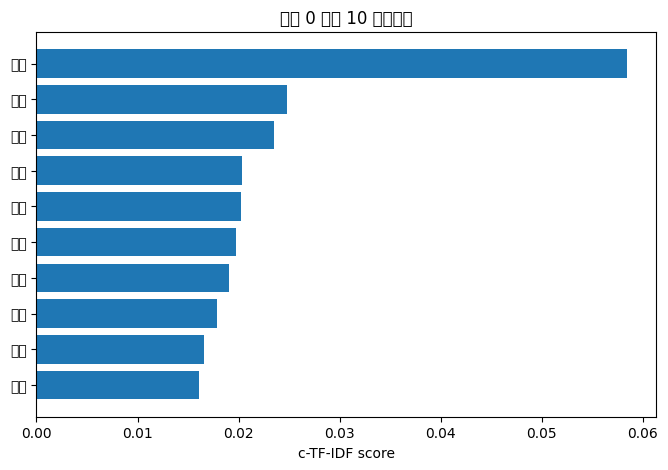

In [ ]:
# 視覺化：主題詞長條圖
try:
    topic_to_view = topic_model.get_topic_info().query('Topic != -1').iloc[0]['Topic']
    topic_words = pd.DataFrame(topic_model.get_topic(topic_to_view), columns=['word', 'score']).head(10)

    plt.figure(figsize=(8, 5))
    plt.barh(topic_words['word'], topic_words['score'])
    plt.gca().invert_yaxis()
    plt.xlabel('c-TF-IDF score')
    plt.title(f'主題 {topic_to_view} 的前 10 個代表詞')
    plt.show()
except Exception as e:
    print('尚無法繪圖，請先成功執行 BERTopic。')
    print(type(e).__name__, e)


### 5.5 使用 Representation 方法微調主題表示

BERTopic 的主題名稱有時只由高頻詞組成，可能不夠直覺。Representation model 可用來優化主題表示，例如：

| Representation 方法 | 作用 |
|---|---|
| `KeyBERTInspired` | 使用 embedding 方式挑選更具代表性的主題詞 |
| `MaximalMarginalRelevance` | 降低主題詞重複性，讓關鍵詞更多元 |
| 自訂主題命名 | 研究者依照代表詞與代表文章人工命名 |

本組資料屬於 PTT 生活情緒文本，因此最後仍建議搭配人工判讀，將主題命名為較容易理解的生活情境，例如「人際關係」、「感情困擾」、「工作壓力」、「家庭事件」、「身體與健康」等。


In [ ]:
try:
    from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance

    representation_model = {
        'KeyBERT': KeyBERTInspired(),
        'MMR': MaximalMarginalRelevance(diversity=0.4)
    }

    refined_topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        language='multilingual',
        top_n_words=12,
        verbose=True
    )

    refined_topics, refined_probs = refined_topic_model.fit_transform(topic_docs, embeddings)
    display(refined_topic_model.get_topic_info().head(15))
except Exception as e:
    print('Representation model 尚未成功執行；若 bertopic 版本較舊，可先升級 bertopic。')
    print(type(e).__name__, e)


2026-05-16 16:16:32,449 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-16 16:16:32,998 - BERTopic - Dimensionality - Completed ✓
2026-05-16 16:16:32,999 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-16 16:16:33,018 - BERTopic - Cluster - Completed ✓
2026-05-16 16:16:33,025 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-16 16:16:40,064 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,KeyBERT,MMR,Representative_Docs
0,-1,78,-1_難過_不是_什麼_可以,"[難過, 不是, 什麼, 可以, 知道, 覺得, 這樣, 一個, 就是, 還是, 如果, 因為]","[難過, 不過, 不到, 失敗, 畢竟, 因為, 但是, 是不是, 本來, 雖然]","[難過, 因為, 衣架, 小孩, 只是, 咖啡, 不能, 玩偶, 問題, 飲料]",[難過 生日前夕被蝦皮賣家搞。我現在很難過 我心情很不好 應徵工作結果應該不順利 五倍券也還沒弄好 還要幫家人弄 政府弄得好複雜 加上我明天生日還不能處理好這件破事 我在蝦皮買了一件褲子 收到以後我發現脫線很嚴重 我先私訊賣家等了一...
1,0,71,0_難過_怎麼_時候_好吃,"[難過, 怎麼, 時候, 好吃, 一個, 就是, 茄子, 東西, 結果, 這樣, 沒有, 可以]","[氣炸鍋, 水餃, 難過, 奇異果, 洗完, 烤盤, 奇怪, 水份, 是不是, 倒閉]","[難過, 怎麼, 時候, 好吃, 沒有, 水餃, 床上, 蟑螂, 烤盤, 很多]",[難過 我的魚魚走了。大家深夜安安 我芙尼 大概一個禮拜前， 我養的鬥魚：藍藍路出現腹水 立鱗的症狀， 他會整隻浮在水面上漂浮， 有時候也會沉在底部。 能做的都做了， 之後我發現他開始掉鱗片， 情況惡化未曾轉好。 他昨天的最後一程，...
2,1,66,1_就是_難過_什麼_戀童,"[就是, 難過, 什麼, 戀童, 我們, 沒有, 他們, 可以, 朋友, 大家, 只是, 受害者]","[難過, 人生, 受害人, 社會, 受害者, 被害人, 生活, 自殺, 因為, 心情]","[難過, 我們, 沒有, 他們, 只是, 受害者, 小孩, 結婚, 因為, 家人]",[難過 富二代其實大多比一般人努力。這串文章我是最贊同 的想法啦 但回到原點 這其實就是價值觀的問題 沒什麼好爭的 懂那篇文章的，會自己摸摸鼻子努力 世界本來就是不公平的 而不懂的，就會想噓爆他，藉此證明自己沒那麼爛，是其他人運氣太...
3,2,32,2_同事_公司_主管_工作,"[同事, 公司, 主管, 工作, 上班, 難過, 時間, 開始, 我媽, 其他, 止痛, 離職]","[離職, 員工, 工友, 下班, 加班, 同事, 上班, 難過, 主管, 店員]","[上班, 時間, 我媽, 止痛, 離職, 明天, 客戶, 小時, 一天, 今天]",[難過 員工疑似偷錢。等有找到證據再說， 不要冤枉人。 因為這事也在我家發生過， 我媽以前有請一個年輕女生當助理， 對方很勤快又認真，我媽也是很喜歡她， 但有一天我媽放在辦公室要拿給客戶的貨款不見了， 她很慌張的東找西找，然後想說放...
4,3,20,3_台灣_中國_難過_用語,"[台灣, 中國, 難過, 用語, 沒有, 什麼, 只有, 心凌, 新竹, 討論, 文化, 女版]","[中國, 中文, 台灣, 台北人, 越南人, 台北, 外國人, 越南, 韓男, 文化]","[台灣, 中國, 難過, 新竹, 討論, 文化, 一堆, 他們, 中文, 妹子]",[難過 台灣的女運動員。謝淑薇止步澳網八強 朋友傳給我她的 文 叫我去給她加油打氣 我看到她的文章超傷心的 感覺運動員退役之後 很少有過的很好的 知名的很少 不知名的 一定就更少了 在訓練的時候身上一堆傷 老了以後後遺症一堆 還在吵...
5,4,19,4_難過_開車_人行道_機車,"[難過, 開車, 人行道, 機車, 車子, 汽車, 看到, 就是, 這樣, 喜歡, 很多, 知道]","[汽車, 車子, 車位, 開車, 飆車, 路邊, 大馬路, 當街, 買車, 這台車]","[難過, 開車, 人行道, 機車, 汽車, 很多, 買車, 老人, 什麼, 視野]",[難過 昨天發生一件事。有一個身障的老人 在別人車子旁邊的圍牆上尿尿 結果車主 趕過來 當街痛罵 可能覺得會噴到他的車子 他身障行動不便 要留不是 要走也不行 像小孩子一樣 在馬路邊聽訓 這件事 其實不想表達意見 懶得抬槓 但又想 ...
6,5,14,5_手機_難過_飛行_手上,"[手機, 難過, 飛行, 手上, 不開, 習慣, 模式, 影響, 一支, 手汗, 小手, 飛機裡]","[連手機, 手機, 買空機, 裸機, 飛機裡, 飛行, 電子鎖, 丟過, 超麻煩, 機了]","[手機, 習慣, 影響, 買空機, 資費, 小米, 裸機, 低收, 電子鎖, 煙火]",[難過 手汗被偵測為長按。一直覺得手機怪怪的 老是卡屏不動 請別人操作就不會 終於發現 原來有問題的不是手機 是我的手汗 按 鍵會判定是長按 剛剛用指節按螢幕就沒事 難過 手汗毀我手機體驗 前幾天指紋解鎖也是被手汗害到 鎖死要另外認...


In [ ]:
try:
    # 1. 取得模型跑出來的主題資訊（排除雜訊 -1）
    topic_info = topic_model.get_topic_info().copy()
    topic_info = topic_info[topic_info['Topic'] != -1].head(10)

    # 2. 這裡建立一個「人工對照表」！
    # 請Peggy先執行一次原本的BERTopic，看看各個 Topic 跑出來的關鍵字是什麼，
    # 然後把下面的 "根據關鍵字手動命名的名稱" 改成你覺得適合的報告主題！
    topic_mapping = {
        0: "生活事件 (對應你模型 Topic 0 的關鍵字)",
        1: "家庭事件 (對應你模型 Topic 1 的關鍵字)",
        2: "政治問題 (對應你模型 Topic 2 的關鍵字)",
        3: "交通問題 (對應你模型 Topic 3 的關鍵字)",
        4: "工作壓力 (對應你模型 Topic 4 的關鍵字)",
        # 如果還有更多 Topic，可以依此類推往下加：
        # 5: "自訂主題名稱",
    }

    rows = []
    for topic_id in topic_info['Topic']:
        # 抓取前 5 個原生關鍵字作為參考
        raw_words = [w for w, s in topic_model.get_topic(topic_id)[:5]]
        keywords_str = ' / '.join(raw_words)

        # 查表，如果還沒設定就先顯示原本的關鍵字
        suggested_name = topic_mapping.get(topic_id, "請觀察關鍵字後手動命名")

        rows.append({
            'Topic 編號': topic_id,
            '模型原生關鍵字 (Representation)': keywords_str,
            '研究者建議主題名稱 (人工命名)': suggested_name
        })

    manual_name_df = pd.DataFrame(rows)
    print("✅ 成功微調主題表示！這樣放進期末報告超專業：")
    display(manual_name_df)

except Exception as e:
    print('尚未成功建立主題模型，因此無法人工命名。')
    print(type(e).__name__, e)

✅ 成功微調主題表示！這樣放進期末報告超專業：


,Topic 編號,模型原生關鍵字 (Representation),研究者建議主題名稱 (人工命名)
0,0,難過 / 怎麼 / 時候 / 好吃 / 這樣,生活事件 (對應你模型 Topic 0 的關鍵字)
1,1,就是 / 難過 / 什麼 / 戀童 / 我們,家庭事件 (對應你模型 Topic 1 的關鍵字)
2,2,台灣 / 中國 / 難過 / 沒有 / 什麼,政治問題 (對應你模型 Topic 2 的關鍵字)
3,3,難過 / 開車 / 人行道 / 機車 / 汽車,交通問題 (對應你模型 Topic 3 的關鍵字)
4,4,公司 / 同事 / 主管 / 工作 / 我媽,工作壓力 (對應你模型 Topic 4 的關鍵字)
5,5,手機 / 難過 / 習慣 / 飛行 / 不開,請觀察關鍵字後手動命名


## 6. 小結：本組第三次報告重點

本次報告將第十二週 BERT 課程內容套用到本組 PTT WomenTalk「難過」貼文資料，主要完成以下工作：

1. **資料前處理**：將原始 PTT CSV 整理為 BERT 可使用的 `doc_text`。
2. **Token Classification / NER**：示範如何使用中文 BERT NER 模型辨識文本中的實體。
3. **Sequence Classification / Sentiment**：使用中文情緒分類模型判斷貼文情緒傾向。
4. **Relation Extraction**：說明 RE 任務概念，並以中文關鍵詞共現作為本組資料的弱監督關係探索。
5. **Text Clustering / BERTopic**：使用中文 embedding、jieba tokenizer 與 BERTopic 找出「難過」貼文中的主要主題。
6. **Representation 微調**：利用 BERTopic 的 representation 方法與人工命名，使主題更容易被課堂聽眾理解。

整體而言，BERT 與 BERTopic 的優勢在於能捕捉語意層次，不只依靠字詞出現次數，因此比傳統 TF-IDF 更適合分析語意相近但用詞不同的中文社群文本。不過，模型結果仍需要搭配研究者判讀，特別是 PTT 這類口語、情緒化、上下文依賴高的資料。


## 7. 期末/課堂報告可口頭說明版本

如果要在簡報中快速說明本 notebook，可使用以下講法：

> 我們第三次報告延續前兩次對 PTT WomenTalk「難過」貼文的分析，這次改用 BERT 相關方法。首先，我們把原始貼文整理成 BERT 可以處理的文本格式，接著示範三種任務：第一是 Token Classification，也就是用 NER 找出文本中的人名、地名或組織名；第二是 Sequence Classification，我們用情緒分類模型判斷貼文情緒，也說明 Relation Extraction 的概念；第三是 Text Clustering，我們使用 BERTopic，把貼文轉成語意向量後進行分群，找出「難過」貼文中常見的主題。最後，我們也使用 Representation 方法和人工命名，讓模型產生的主題更容易解釋。這次分析顯示，BERT 類方法可以補足傳統斷詞與 TF-IDF 只看表面詞頻的限制，更能捕捉社群文本背後的語意與情境。
